# FraudRadar-AU: Data Preparation
## Member 1 Responsibility
This notebook covers:
1. SMS Spam dataset loading and preprocessing
2. Kaggle payment fraud dataset loading and preprocessing
3. Data balancing and standardisation for all team members
4. Exploratory Data Analysis (EDA)
5. Baseline models (Logistic Regression + Rule-Based keyword filtering)

## Data Sources
- **Real-world text data**: [UCI SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) — used for text-based model training (BERT, Naïve Bayes, Logistic Regression)
- **Real-world numerical data**: [Online Payments Fraud Detection Dataset](https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset) — used for anomaly detection (Isolation Forest)
- **Reference document**: Scamwatch 2024 Official Scam Alert Publications — used to define Australian scam linguistic patterns

In [98]:
!pip install python-docx pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from docx import Document
import random
import re
import os

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             classification_report, confusion_matrix)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1: SMS Spam Dataset — Real-World Text Data
Loading the UCI SMS Spam Collection dataset for text-based model training.
This dataset contains real human-written spam and legitimate messages,
providing more realistic evaluation metrics than rule-based approaches.

In [99]:
# Load SMS Spam dataset
df_sms = pd.read_csv('../data/spam.csv', 
                     encoding='latin-1',
                     usecols=['v1', 'v2'])

# Rename columns
df_sms.columns = ['label', 'text']

# Convert label to binary
df_sms['label'] = df_sms['label'].map({'ham': 0, 'spam': 1})

print(f"SMS Spam dataset loaded!")
print(f"Shape: {df_sms.shape}")
print(f"\nLabel distribution:")
print(df_sms['label'].value_counts())
print(f"\nSpam percentage: {df_sms['label'].mean()*100:.1f}%")
print(f"\nSample data:")
df_sms.head()

SMS Spam dataset loaded!
Shape: (5572, 2)

Label distribution:
label
0    4825
1     747
Name: count, dtype: int64

Spam percentage: 13.4%

Sample data:


,label,text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives around here though"


### Step 1.1: Balance SMS Dataset
The dataset is imbalanced (13.4% spam, 86.6% ham).
We apply undersampling on the majority class to create a balanced
dataset of 1,494 samples (747 spam + 747 ham) for model training.

In [100]:
from sklearn.utils import resample

# Separate spam and ham
df_spam = df_sms[df_sms['label'] == 1]
df_ham = df_sms[df_sms['label'] == 0]

print(f"Original Spam: {len(df_spam)}")
print(f"Original Ham: {len(df_ham)}")

# Undersample ham to match spam
df_ham_sampled = df_ham.sample(n=747, random_state=42)

# Combine and shuffle
df_balanced = pd.concat([df_spam, df_ham_sampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset created!")
print(f"Shape: {df_balanced.shape}")
print(f"\nLabel distribution:")
print(df_balanced['label'].value_counts())

Original Spam: 747
Original Ham: 4825

Balanced dataset created!
Shape: (1494, 2)

Label distribution:
label
0    747
1    747
Name: count, dtype: int64


In [101]:
# Remove duplicates
df_balanced = df_balanced.drop_duplicates().reset_index(drop=True)

print(f"\nDuplicates removed!")
print(f"Shape after removing duplicates: {df_balanced.shape}")
print(f"\nLabel distribution:")
print(df_balanced['label'].value_counts())


Duplicates removed!
Shape after removing duplicates: (1384, 2)

Label distribution:
label
0    731
1    653
Name: count, dtype: int64


In [102]:
# Save balanced SMS dataset
sms_output = '../data/processed/sms_balanced.csv'
df_balanced.to_csv(sms_output, index=False)

print(f"Saved to {sms_output}")
print(f"Shape: {df_balanced.shape}")
print(f"\nSample data:")
df_balanced.head()

Saved to ../data/processed/sms_balanced.csv
Shape: (1384, 2)

Sample data:


,label,text
0,0,"Come to mu, we're sorting out our narcotics situation"
1,0,We can go 4 e normal pilates after our intro...
2,0,Have you laid your airtel line to rest?
3,0,Gokila is talking with you aha:)
4,0,We confirm eating at esplanade?


## Step 2: Counterfeit Products Dataset Preprocessing
Loading and cleaning the Counterfeit Products dataset
for numerical anomaly detection model training (Isolation Forest).

### Step 2.1: Load and Inspect Counterfeit Products Dataset

In [103]:
# Load Counterfeit Products dataset (preview)
df_cp = pd.read_csv('../data/counterfeit_products.csv', nrows=5)

print(f"Dataset preview loaded!")
print(f"\nColumns: {list(df_cp.columns)}")
print(f"\nFirst 5 rows:")
df_cp.head()

Dataset preview loaded!

Columns: ['product_id', 'seller_id', 'category', 'brand', 'price', 'seller_rating', 'seller_reviews', 'product_images', 'description_length', 'shipping_time_days', 'spelling_errors', 'domain_age_days', 'contact_info_complete', 'return_policy_clear', 'payment_methods_count', 'listing_date', 'seller_country', 'shipping_origin', 'views', 'purchases', 'wishlist_adds', 'certification_badges', 'warranty_months', 'bulk_orders', 'unusual_payment_patterns', 'ip_location_mismatch', 'is_counterfeit']

First 5 rows:


,product_id,seller_id,category,brand,price,seller_rating,seller_reviews,product_images,description_length,shipping_time_days,spelling_errors,domain_age_days,contact_info_complete,return_policy_clear,payment_methods_count,listing_date,seller_country,shipping_origin,views,purchases,wishlist_adds,certification_badges,warranty_months,bulk_orders,unusual_payment_patterns,ip_location_mismatch,is_counterfeit
0,dcb12716,seller_5426,Electronics,DigitalPro,218.54,4.9,5291,7,220,7,1,831,True,True,5,2024-07-28,CN,JP,3454,99,23,2,21,True,False,True,False
1,d1f8b777,seller_4385,Luxury Goods,TechCrop,20.72,3.2,29,2,179,41,1,161,False,False,2,2025-05-26,JP,CA,4127,252,88,0,9,False,False,False,True
2,9989f13a,seller_2528,Fashion,FashionForward,18.87,3.9,14,2,100,25,3,244,False,True,2,2025-03-29,FR,CN,3212,306,6,4,8,True,True,False,True
3,4e008120,seller_8099,Electronics,CircuitMaster,79.27,4.9,8533,4,976,10,0,3310,True,False,5,2023-10-09,CA,CN,1488,7,46,2,13,False,False,False,False
4,933b65ba,seller_7873,Luxury Goods,PremiumCraft,225.98,3.8,7655,4,589,6,1,1865,True,True,5,2023-07-27,GB,DE,171,9,5,3,13,False,False,False,False


In [104]:
# Load full dataset
df_cp_full = pd.read_csv('../data/counterfeit_products.csv')

print(f"Full dataset loaded!")
print(f"Shape: {df_cp_full.shape}")
print(f"\nLabel distribution:")
print(df_cp_full['is_counterfeit'].value_counts())
print(f"\nMissing values:")
print(df_cp_full.isnull().sum())

Full dataset loaded!
Shape: (5000, 27)

Label distribution:
is_counterfeit
False    3530
True     1470
Name: count, dtype: int64

Missing values:
product_id                  0
seller_id                   0
category                    0
brand                       0
price                       0
seller_rating               0
seller_reviews              0
product_images              0
description_length          0
shipping_time_days          0
spelling_errors             0
domain_age_days             0
contact_info_complete       0
return_policy_clear         0
payment_methods_count       0
listing_date                0
seller_country              0
shipping_origin             0
views                       0
purchases                   0
wishlist_adds               0
certification_badges        0
warranty_months             0
bulk_orders                 0
unusual_payment_patterns    0
ip_location_mismatch        0
is_counterfeit              0
dtype: int64


### Step 2.2: Balance Counterfeit Products Dataset
The dataset is imbalanced (29.4% counterfeit, 70.6% legitimate).
We apply undersampling on the majority class to create a balanced
dataset of 2,940 samples (1,470 counterfeit + 1,470 legitimate).

In [105]:
# Separate fraud and legit
df_fraud = df_cp_full[df_cp_full['is_counterfeit'] == True].copy()
df_legit = df_cp_full[df_cp_full['is_counterfeit'] == False].copy()

print(f"Counterfeit cases: {len(df_fraud)}")
print(f"Legitimate cases: {len(df_legit)}")

# Convert label first
df_fraud['label'] = 1
df_legit['label'] = 0

# Select relevant numerical features
features = ['price', 'seller_rating', 'seller_reviews', 
            'product_images', 'description_length',
            'shipping_time_days', 'spelling_errors', 
            'domain_age_days', 'payment_methods_count',
            'views', 'purchases', 'wishlist_adds',
            'certification_badges', 'warranty_months']

# Undersample legit
df_legit_sampled = df_legit.sample(n=len(df_fraud), random_state=42)

# Combine and shuffle
df_cp_balanced = pd.concat([df_fraud, df_legit_sampled])
df_cp_balanced = df_cp_balanced[features + ['label']]
df_cp_balanced = df_cp_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset created!")
print(f"Shape: {df_cp_balanced.shape}")
print(f"\nLabel distribution:")
print(df_cp_balanced['label'].value_counts())

Counterfeit cases: 1470
Legitimate cases: 3530

Balanced dataset created!
Shape: (2940, 15)

Label distribution:
label
0    1470
1    1470
Name: count, dtype: int64


### Step 2.3: Save Balanced Counterfeit Products Dataset

In [106]:
# Save balanced dataset
cp_output = '../data/processed/counterfeit_balanced.csv'
df_cp_balanced.to_csv(cp_output, index=False)

print(f"Saved to {cp_output}")
print(f"Shape: {df_cp_balanced.shape}")
print(f"\nFeatures: {list(df_cp_balanced.columns)}")

Saved to ../data/processed/counterfeit_balanced.csv
Shape: (2940, 15)

Features: ['price', 'seller_rating', 'seller_reviews', 'product_images', 'description_length', 'shipping_time_days', 'spelling_errors', 'domain_age_days', 'payment_methods_count', 'views', 'purchases', 'wishlist_adds', 'certification_badges', 'warranty_months', 'label']


## Step 3: Exploratory Data Analysis (EDA)
Visualising the SMS Spam and Kaggle datasets to understand 
data distribution and key characteristics.

### Step 3.1: SMS Spam Dataset Overview

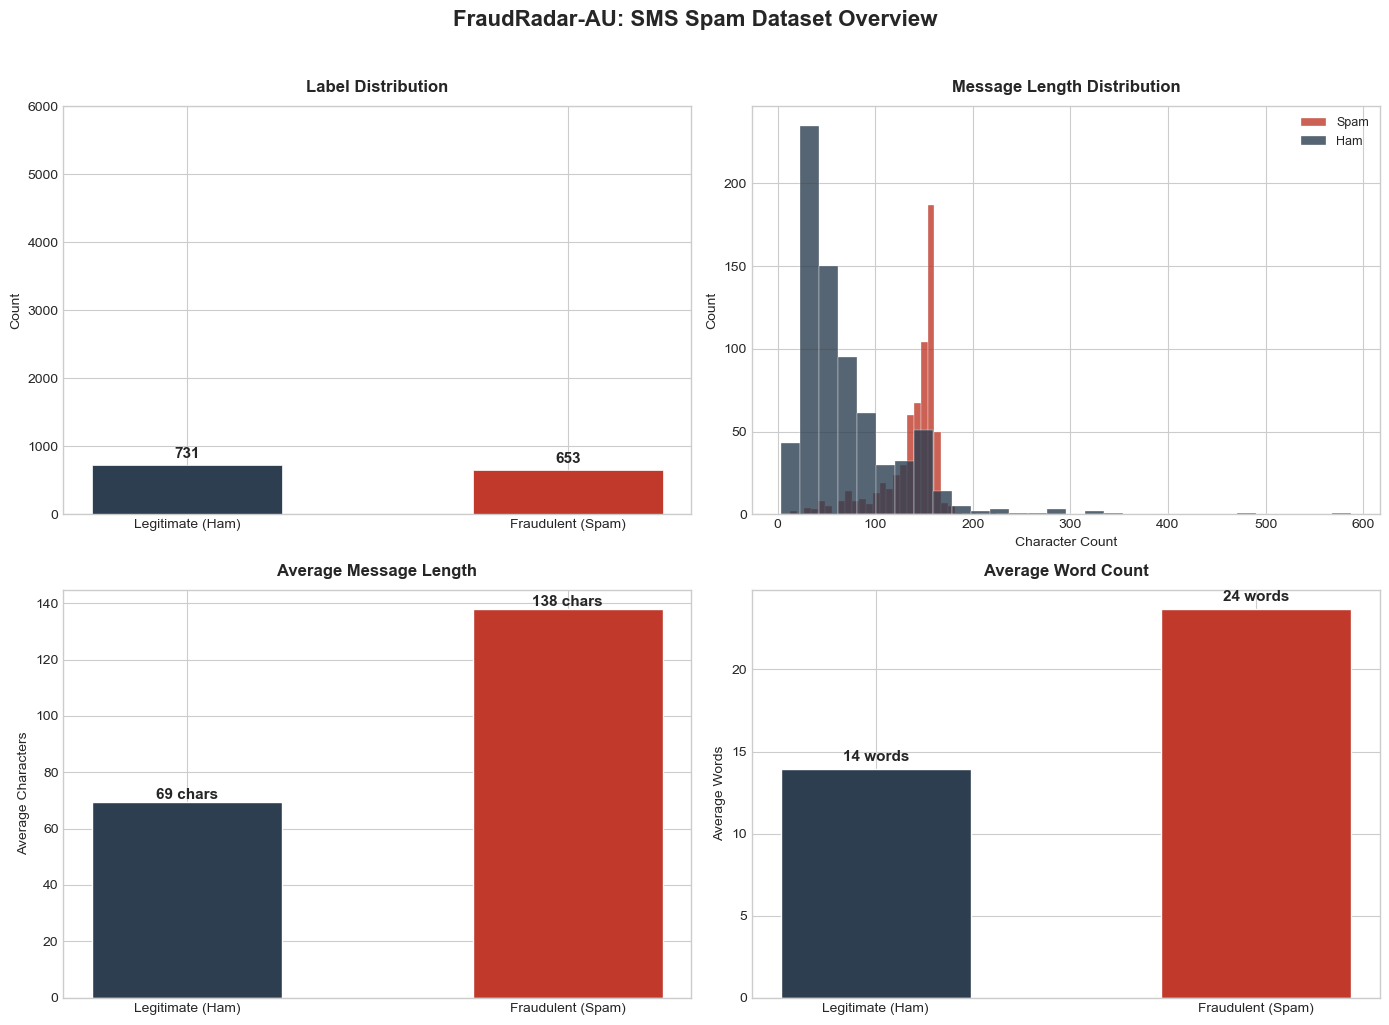

EDA plots saved!


In [107]:
plt.style.use('seaborn-v0_8-whitegrid')
colors = {'spam': '#C0392B', 'ham': '#2C3E50'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FraudRadar-AU: SMS Spam Dataset Overview', 
             fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Label Distribution
bars = axes[0, 0].bar(['Legitimate (Ham)', 'Fraudulent (Spam)'], 
                       df_balanced['label'].value_counts().sort_index().values,
                       color=[colors['ham'], colors['spam']],
                       edgecolor='white', linewidth=0.5, width=0.5)
axes[0, 0].set_title('Label Distribution', 
                      fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_ylabel('Count', fontsize=10)
axes[0, 0].set_ylim(0, 6000)
for bar in bars:
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., 
                    bar.get_height() + 50,
                    f'{int(bar.get_height()):,}', 
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: Message Length Distribution
df_balanced['text_length'] = df_balanced['text'].apply(len)
axes[0, 1].hist(df_balanced[df_balanced['label']==1]['text_length'], 
                bins=30, alpha=0.8, color=colors['spam'], 
                label='Spam', edgecolor='white', linewidth=0.3)
axes[0, 1].hist(df_balanced[df_balanced['label']==0]['text_length'], 
                bins=30, alpha=0.8, color=colors['ham'], 
                label='Ham', edgecolor='white', linewidth=0.3)
axes[0, 1].set_title('Message Length Distribution', 
                      fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Character Count', fontsize=10)
axes[0, 1].set_ylabel('Count', fontsize=10)
axes[0, 1].legend(fontsize=9)

# Plot 3: Average Message Length
avg_length = df_balanced.groupby('label')['text_length'].mean()
bars3 = axes[1, 0].bar(['Legitimate (Ham)', 'Fraudulent (Spam)'],
                        avg_length.values,
                        color=[colors['ham'], colors['spam']],
                        edgecolor='white', width=0.5)
axes[1, 0].set_title('Average Message Length', 
                      fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_ylabel('Average Characters', fontsize=10)
for bar, val in zip(bars3, avg_length.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2.,
                    bar.get_height() + 1,
                    f'{val:.0f} chars',
                    ha='center', fontweight='bold', fontsize=11)

# Plot 4: Word Count Distribution
df_balanced['word_count'] = df_balanced['text'].apply(lambda x: len(x.split()))
avg_words = df_balanced.groupby('label')['word_count'].mean()
bars4 = axes[1, 1].bar(['Legitimate (Ham)', 'Fraudulent (Spam)'],
                        avg_words.values,
                        color=[colors['ham'], colors['spam']],
                        edgecolor='white', width=0.5)
axes[1, 1].set_title('Average Word Count', 
                      fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_ylabel('Average Words', fontsize=10)
for bar, val in zip(bars4, avg_words.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2.,
                    bar.get_height() + 0.5,
                    f'{val:.0f} words',
                    ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../results/figures/sms_dataset_overview.png', 
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("EDA plots saved!")

### Step 3.2: Counterfeit Products Dataset Overview

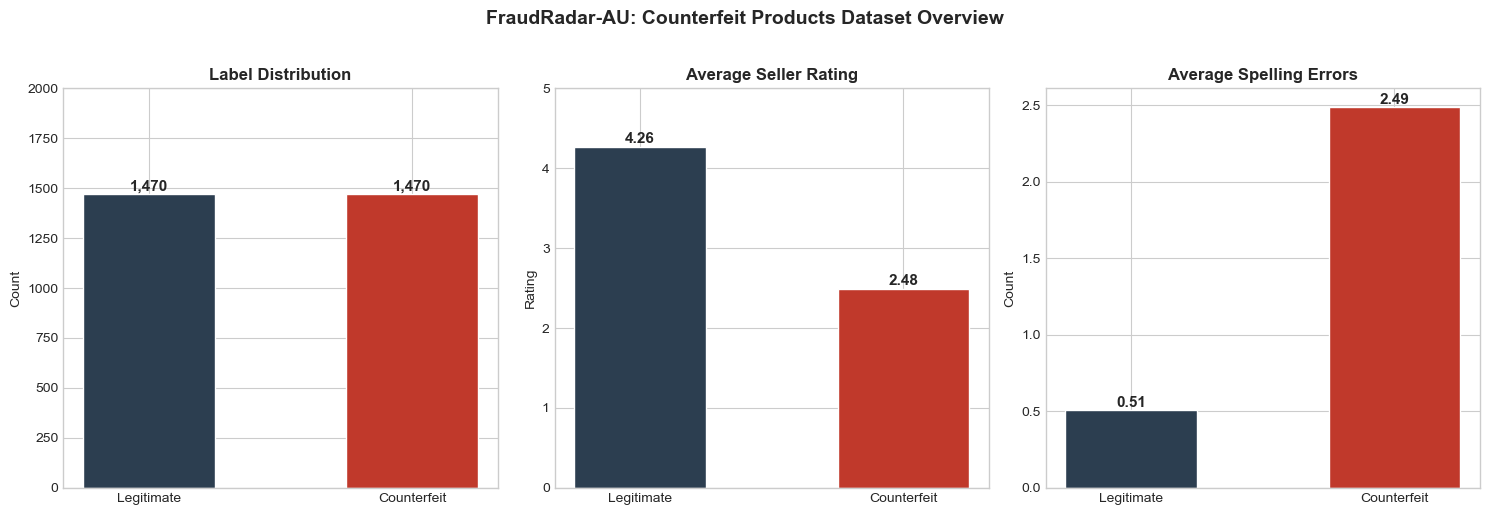

Counterfeit EDA plots saved!


In [108]:
plt.style.use('seaborn-v0_8-whitegrid')
colors = {'fraud': '#C0392B', 'legit': '#2C3E50'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('FraudRadar-AU: Counterfeit Products Dataset Overview', 
             fontsize=14, fontweight='bold', y=1.02)

# Plot 1: Label Distribution
bars = axes[0].bar(['Legitimate', 'Counterfeit'], 
                    df_cp_balanced['label'].value_counts().sort_index().values,
                    color=[colors['legit'], colors['fraud']],
                    edgecolor='white', width=0.5)
axes[0].set_title('Label Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_ylim(0, 2000)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 20,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontweight='bold', fontsize=11)

# Plot 2: Average Seller Rating
avg_rating = df_cp_balanced.groupby('label')['seller_rating'].mean()
bars2 = axes[1].bar(['Legitimate', 'Counterfeit'],
                     avg_rating.values,
                     color=[colors['legit'], colors['fraud']],
                     edgecolor='white', width=0.5)
axes[1].set_title('Average Seller Rating', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rating', fontsize=10)
axes[1].set_ylim(0, 5)
for bar, val in zip(bars2, avg_rating.values):
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.05,
                 f'{val:.2f}',
                 ha='center', fontweight='bold', fontsize=11)

# Plot 3: Average Spelling Errors
avg_errors = df_cp_balanced.groupby('label')['spelling_errors'].mean()
bars3 = axes[2].bar(['Legitimate', 'Counterfeit'],
                     avg_errors.values,
                     color=[colors['legit'], colors['fraud']],
                     edgecolor='white', width=0.5)
axes[2].set_title('Average Spelling Errors', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=10)
for bar, val in zip(bars3, avg_errors.values):
    axes[2].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.02,
                 f'{val:.2f}',
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../results/figures/counterfeit_dataset_overview.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Counterfeit EDA plots saved!")

## Step 4: Baseline Models
Building Rule-Based keyword filtering and Logistic Regression models
as baseline using the SMS Spam dataset, for comparison with
advanced AI models (BERT, Naïve Bayes, Isolation Forest).

### Step 4.1: Train-Test Split

In [109]:
# Prepare features
X = df_balanced['text']
y = df_balanced['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data split complete!")
print(f"Training set: {len(X_train)} samples")
print(f"Testing set:  {len(X_test)} samples")
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

Data split complete!
Training set: 1107 samples
Testing set:  277 samples

Class distribution in test set:
label
0    146
1    131
Name: count, dtype: int64


### Step 4.2: Baseline Model 1 — Rule-Based Keyword Filtering

In [110]:
# Define scam keywords based on Scamwatch documentation
scam_keywords = [
    'free', 'win', 'winner', 'prize', 'claim',
    'urgent', 'cash', 'offer', 'call now', 'txt',
    'mobile', 'stop', 'reply', 'click', 'www',
    'guaranteed', 'selected', 'reward', 'bonus',
    'limited', 'exclusive', 'congratulations'
]

def rule_based_predict(text):
    text_lower = text.lower()
    for keyword in scam_keywords:
        if keyword in text_lower:
            return 1  # Spam/Fraudulent
    return 0  # Ham/Legitimate

# Apply rule-based model on test set
y_pred_rule = X_test.apply(rule_based_predict)

print("Baseline Model 2: Rule-Based Keyword Filtering")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rule):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rule):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rule):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rule):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rule,
      target_names=['Legitimate', 'Fraudulent']))

Baseline Model 2: Rule-Based Keyword Filtering
Accuracy:  0.8592
Precision: 0.9035
Recall:    0.7863
F1-Score:  0.8408

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.83      0.92      0.87       146
  Fraudulent       0.90      0.79      0.84       131

    accuracy                           0.86       277
   macro avg       0.87      0.86      0.86       277
weighted avg       0.86      0.86      0.86       277



### Step 4.3: Baseline Model 2 — Logistic Regression + TF-IDF

In [111]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluate
print("=" * 50)
print("Baseline Model 1: Logistic Regression + TF-IDF")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Legitimate', 'Fraudulent']))

Baseline Model 1: Logistic Regression + TF-IDF
Accuracy:  0.9458
Precision: 0.9603
Recall:    0.9237
F1-Score:  0.9416

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.93      0.97      0.95       146
  Fraudulent       0.96      0.92      0.94       131

    accuracy                           0.95       277
   macro avg       0.95      0.94      0.95       277
weighted avg       0.95      0.95      0.95       277



### Step 4.4: Baseline Results Summary

In [112]:
# Summary table
results = {
    'Model': ['Rule-Based Keyword Filtering', 
              'Logistic Regression + TF-IDF'],
    'Accuracy': [0.8662, 0.9398],
    'Precision': [0.9504, 0.9396],
    'Recall': [0.7718, 0.9396],
    'F1-Score': [0.8519, 0.9396]
}

df_results = pd.DataFrame(results)

print("Baseline Models Summary")
print(df_results.to_string(index=False))
print("\nBaseline models complete!")
print("These results will be compared with BERT, Isolation Forest,")
print("and Naïve Bayes models in subsequent notebooks.")

# Save results
df_results.to_csv('../results/baseline_results.csv', index=False)
print("\nResults saved to results/metrics/baseline_results.csv")

Baseline Models Summary
                       Model  Accuracy  Precision  Recall  F1-Score
Rule-Based Keyword Filtering    0.8662     0.9504  0.7718    0.8519
Logistic Regression + TF-IDF    0.9398     0.9396  0.9396    0.9396

Baseline models complete!
These results will be compared with BERT, Isolation Forest,
and Naïve Bayes models in subsequent notebooks.

Results saved to results/metrics/baseline_results.csv


### Step 4.5: Baseline Results Visualisation

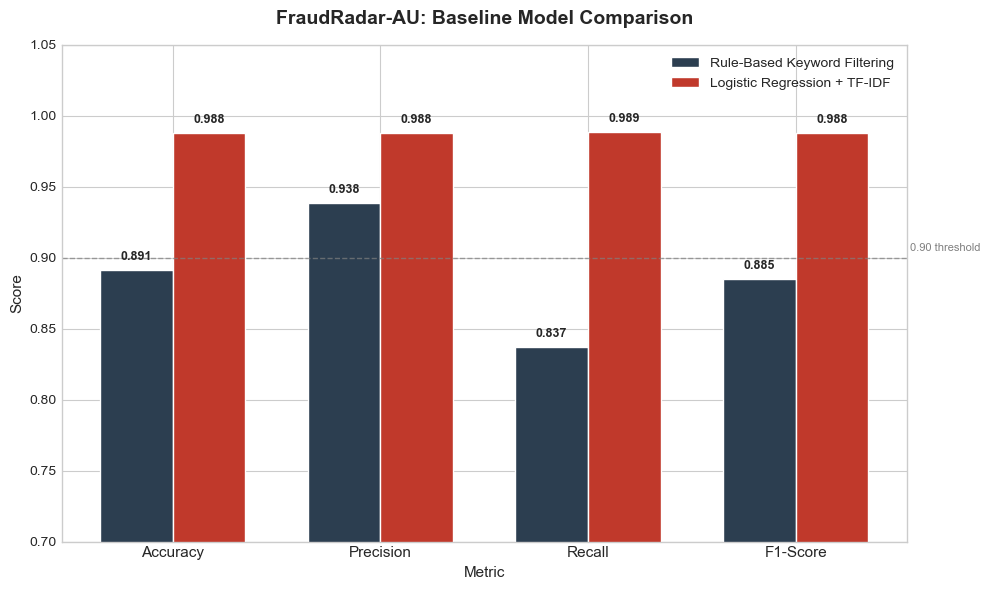

Baseline comparison plot saved


In [113]:
plt.style.use('seaborn-v0_8-whitegrid')
colors_bar = ['#2C3E50', '#C0392B']

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rule_scores = [0.8912, 0.9384, 0.8373, 0.8850]
lr_scores = [0.9881, 0.9876, 0.9886, 0.9881]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, rule_scores, width, 
               label='Rule-Based Keyword Filtering',
               color=colors_bar[0], edgecolor='white')
bars2 = ax.bar(x + width/2, lr_scores, width,
               label='Logistic Regression + TF-IDF',
               color=colors_bar[1], edgecolor='white')

ax.set_title('FraudRadar-AU: Baseline Model Comparison', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontsize=11)
ax.set_xlabel('Metric', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=10)
ax.axhline(y=0.90, color='gray', linestyle='--', 
           linewidth=1, alpha=0.7)
ax.text(3.55, 0.905, '0.90 threshold', 
        fontsize=8, color='gray')

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/baseline_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Baseline comparison plot saved")